In [1]:
import math 
import numpy as np 
import matplotlib.pyplot as py
%matplotlib inline 

In [3]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data 
        self.grad = 0
        self._prev = set(_children)
        self._op = _op
        self.label = label 
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out

    def __mul__(self,other):
        out = Value(self.data * other.data, (self, other), '*')
        return out 

    def __pow__(self, other): 
        assert isinstance(other, (int, float)), "only supoorting int/float powers"
        out = Value(self ** other, (self, ), f'**{other}')

    def __radd__(self, other): # other + self
        return self + other 
        
    def __rmul__(self, other): # other * self 
        return self * other 

    def __truediv__(self, other): 
        return self * (other ** -1)

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)
        
    def tanh(self):
        x = self.data
        n = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(n, (self, ), 'tanh')
        return out 

    def exp(self):
        x = self.data 
        n = math.exp(x)
        out = Value(n, (self, ), 'exp')
        return out 
        
        


In [5]:
a = Value(3.0, label = 'a')
b = Value(2.0, label = 'b')
e = a * b; e.label = 'e'
c = Value(-2.0, label = 'c')
d = e + c; d.label = 'd'
d 

Value(data=4.0)

In [7]:
import os
os.environ["PATH"] += os.pathsep + "/opt/homebrew/bin"

In [9]:
!pip install graphviz

In [11]:
import graphviz

In [13]:
# to visualize our backprop staretgy 
from graphviz import Digraph 
def trace(root):
    #builds set of all nodes n edges in a grpah
    nodes,edges=set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot=Digraph(format='svg',graph_attr={'rankdir':'LR'}) #LR=left to right

    nodes,edges=trace(root)
    for n in nodes:
        uid=str(id(n))
        dot.node(name=uid,label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=uid+n._op,label=n._op)
            dot.edge(uid+n._op,uid)
    for n1,n2 in edges:
        dot.edge(str(id(n1)),str(id(n2)) + n2._op)
    return dot 
    

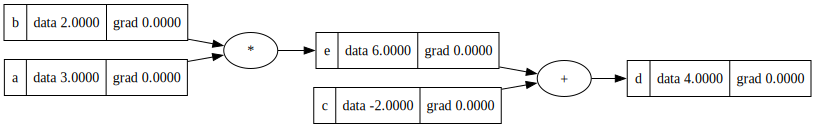

In [15]:
draw_dot(d)